## Análisis Exploratorio de Datos - Análisis Bivariable

### By:
Rafael Garcia

### Date:
2026-08-20

### Description:

Este notebook corresponde a la **Tarea 3: Análisis Exploratorio de Datos (EDA)** del Proyecto 1 del curso de MLOps.

En esta segunda parte se realiza el **análisis bivariable**, estudiando las relaciones entre pares de atributos y especialmente la relación de cada atributo con la variable objetivo (`medv`).

## 📚 Import libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)

## 💾 Load data

In [2]:
df = pd.read_parquet("../../data/02_intermediate/boston_housing_clean.parquet")

TARGET = "medv"
ID_COL = "ID"
NUMERIC_COLS = ["crim", "zn", "indus", "nox", "rm", "age", "dis", "tax", "ptratio", "black", "lstat"]

print(f"Dimensiones: {df.shape}")
df.head()

Dimensiones: (448, 15)


,ID,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,black,lstat,medv
0,1,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.90,4.98,24.0
1,2,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14,21.6
2,4,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3,222.0,18.7,394.63,2.94,33.4
3,5,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3,222.0,18.7,396.90,5.33,NaN
4,7,0.08829,12.5,7.87,0.0,0.524,6.012,66.6,5.5605,5,311.0,15.2,395.60,12.43,22.9


## 🔍 Análisis Bivariable

### Relación de cada variable numérica con `medv`

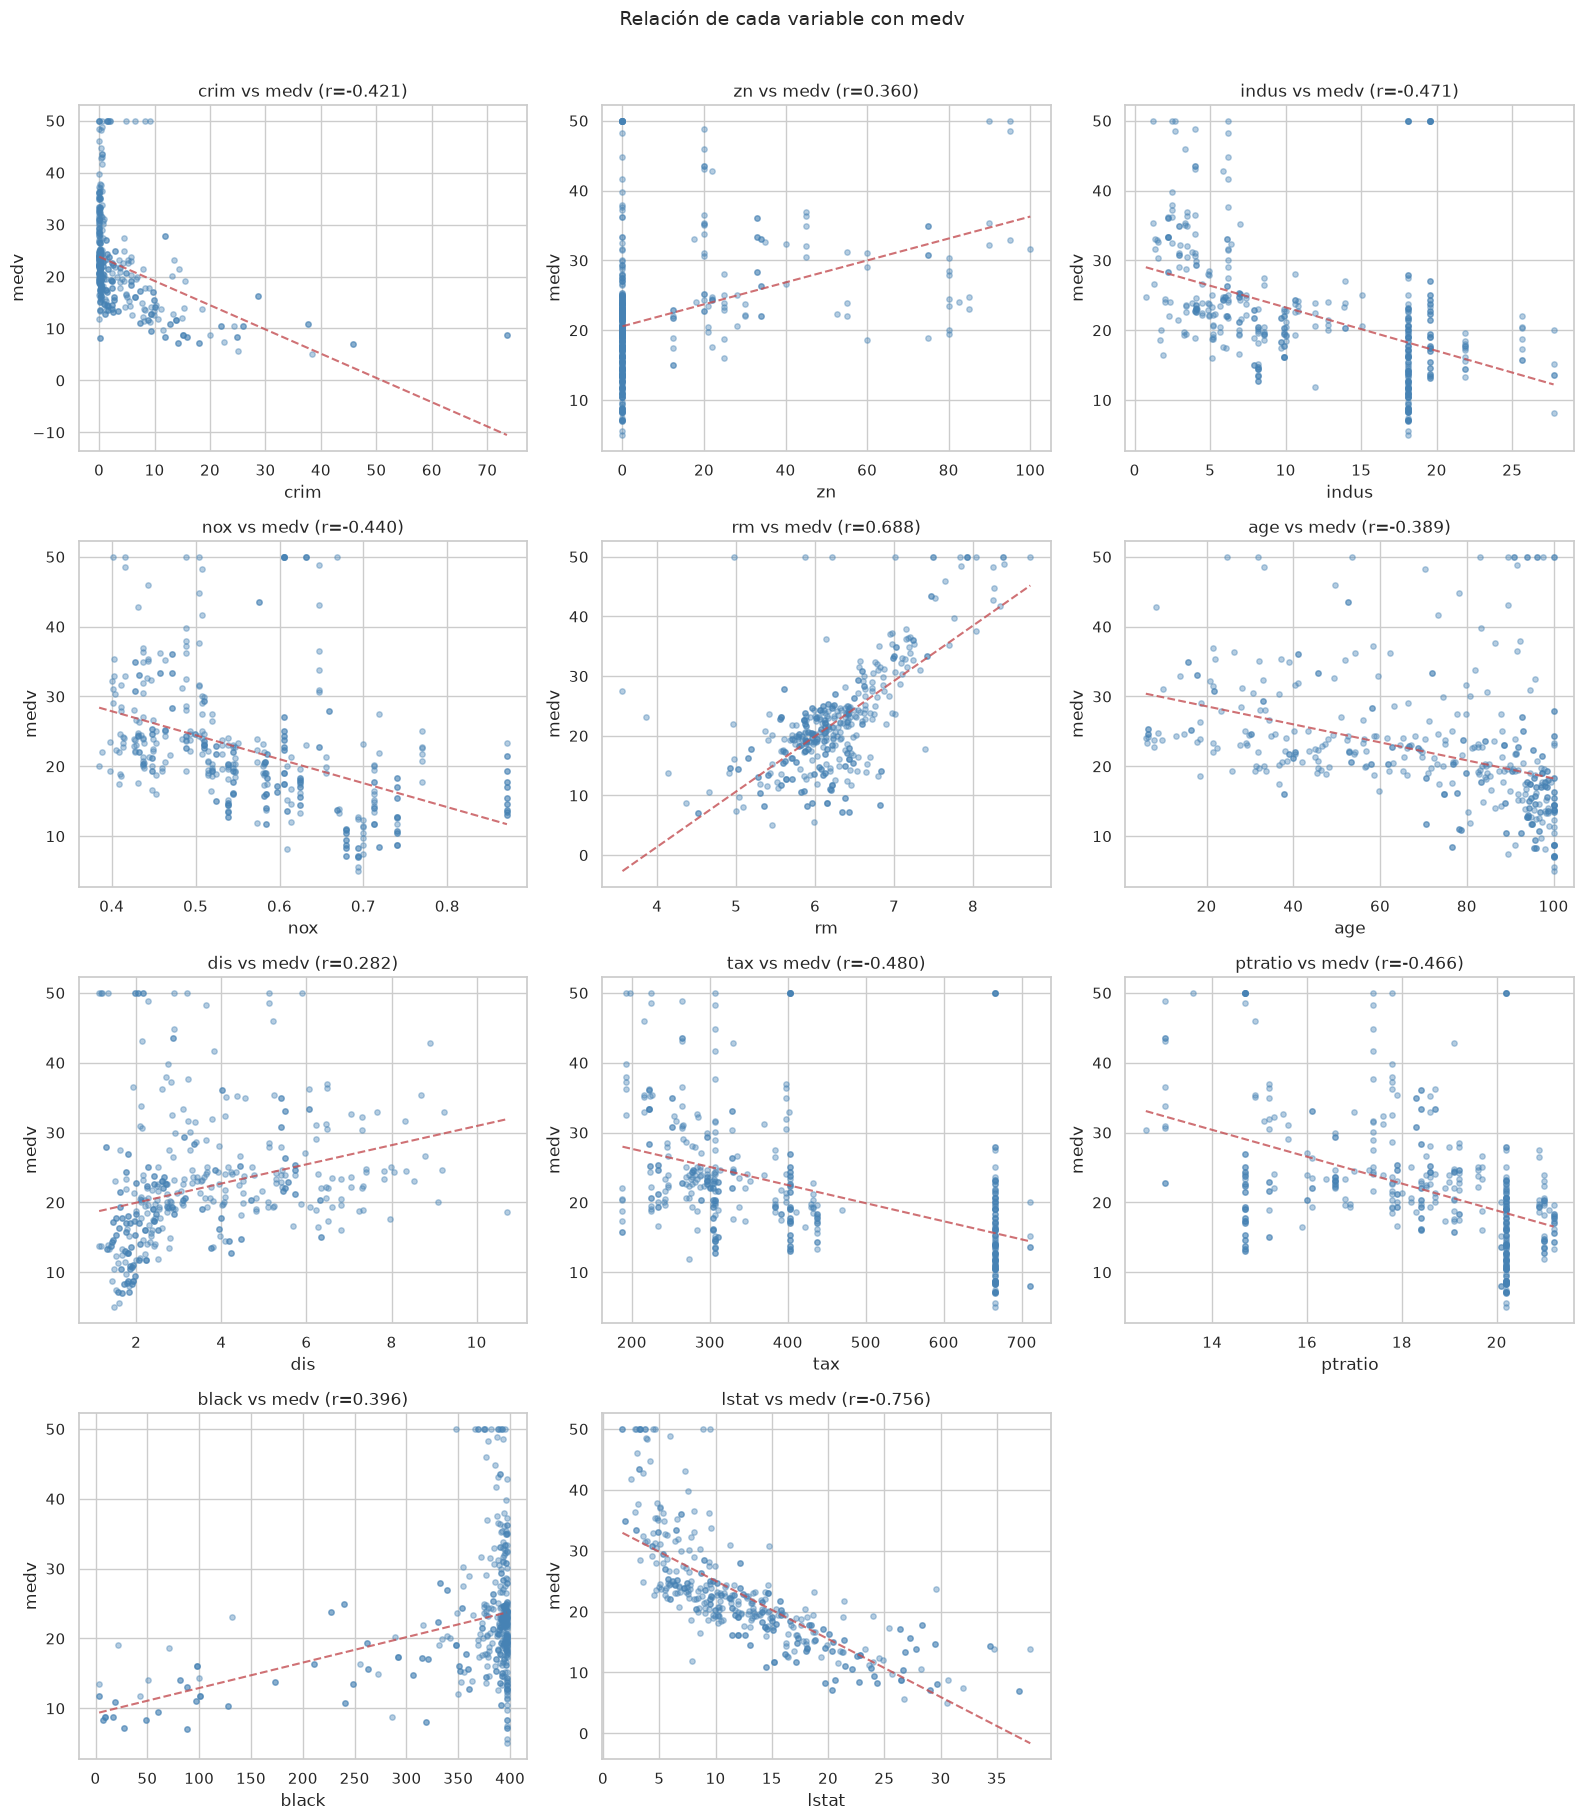

In [3]:
# Scatter plots de cada variable vs medv
fig, axes = plt.subplots(4, 3, figsize=(16, 18))
axes = axes.flatten()

for i, col in enumerate(NUMERIC_COLS):
    mask = df[[col, TARGET]].dropna().index
    x = df.loc[mask, col]
    y = df.loc[mask, TARGET]
    axes[i].scatter(x, y, alpha=0.4, s=15, color="steelblue")
    # Línea de tendencia
    z = np.polyfit(x, y, 1)
    p = np.poly1d(z)
    x_sorted = np.sort(x)
    axes[i].plot(x_sorted, p(x_sorted), "r--", alpha=0.8)
    corr = x.corr(y)
    axes[i].set_title(f"{col} vs {TARGET} (r={corr:.3f})")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel(TARGET)

# Ocultar eje sobrante
axes[11].set_visible(False)

plt.suptitle("Relación de cada variable con medv", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

In [4]:
# Correlación de Pearson y Spearman con medv
print("=== Correlación con medv ===")
print(f"{'Variable':<12} {'Pearson':>10} {'Spearman':>10} {'Relación':>15}")
print("-" * 50)

for col in NUMERIC_COLS:
    mask = df[[col, TARGET]].dropna().index
    pearson = df.loc[mask, col].corr(df.loc[mask, TARGET])
    spearman = df.loc[mask, col].corr(df.loc[mask, TARGET], method="spearman")
    strength = "Fuerte" if abs(pearson) > 0.5 else "Moderada" if abs(pearson) > 0.3 else "Débil"
    direction = "(+)" if pearson > 0 else "(-)"
    print(f"{col:<12} {pearson:>10.4f} {spearman:>10.4f} {strength + ' ' + direction:>15}")

=== Correlación con medv ===
Variable        Pearson   Spearman        Relación
--------------------------------------------------
crim            -0.4210    -0.5917    Moderada (-)
zn               0.3597     0.4493    Moderada (+)
indus           -0.4706    -0.5612    Moderada (-)
nox             -0.4396    -0.5931    Moderada (-)
rm               0.6885     0.5916      Fuerte (+)
age             -0.3891    -0.5813    Moderada (-)
dis              0.2822     0.4826       Débil (+)
tax             -0.4803    -0.5839    Moderada (-)
ptratio         -0.4661    -0.5190    Moderada (-)
black            0.3958     0.2271    Moderada (+)
lstat           -0.7558    -0.8761      Fuerte (-)


### Relaciones más fuertes con `medv`

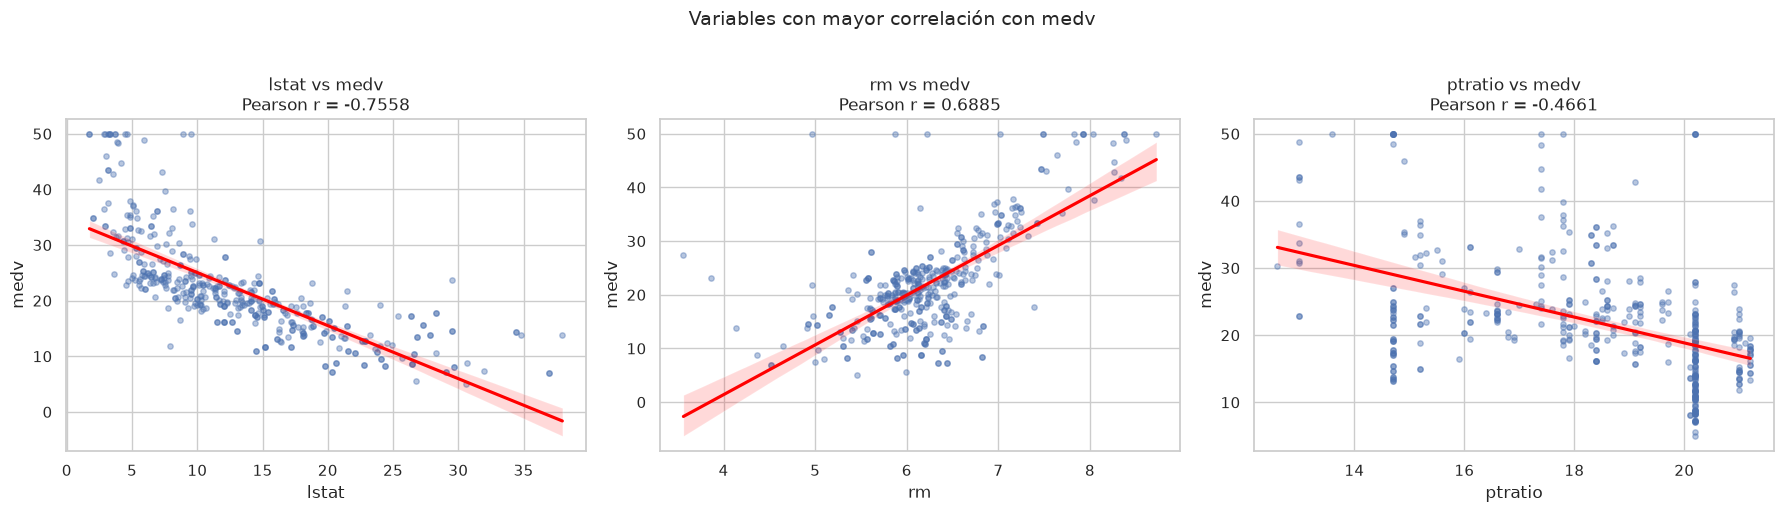

In [5]:
# Detalle de las 3 variables más correlacionadas con medv
TOP_VARS = ["lstat", "rm", "ptratio"]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, col in enumerate(TOP_VARS):
    mask = df[[col, TARGET]].dropna().index
    x = df.loc[mask, col]
    y = df.loc[mask, TARGET]
    sns.regplot(x=x, y=y, ax=axes[i], scatter_kws={"alpha": 0.4, "s": 15}, line_kws={"color": "red"})
    corr = x.corr(y)
    axes[i].set_title(f"{col} vs {TARGET}\nPearson r = {corr:.4f}")

plt.suptitle("Variables con mayor correlación con medv", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

### Relación de variables categóricas/ordinales con `medv`

=== medv por chas ===
         mean  median      std  count
chas                                 
0.0   21.5720   20.40   8.7690    407
1.0   29.6208   26.05  12.7763     24

Test Mann-Whitney U: estadístico=3022.50, p-value=0.001698
Diferencia significativa: Sí (α=0.05)


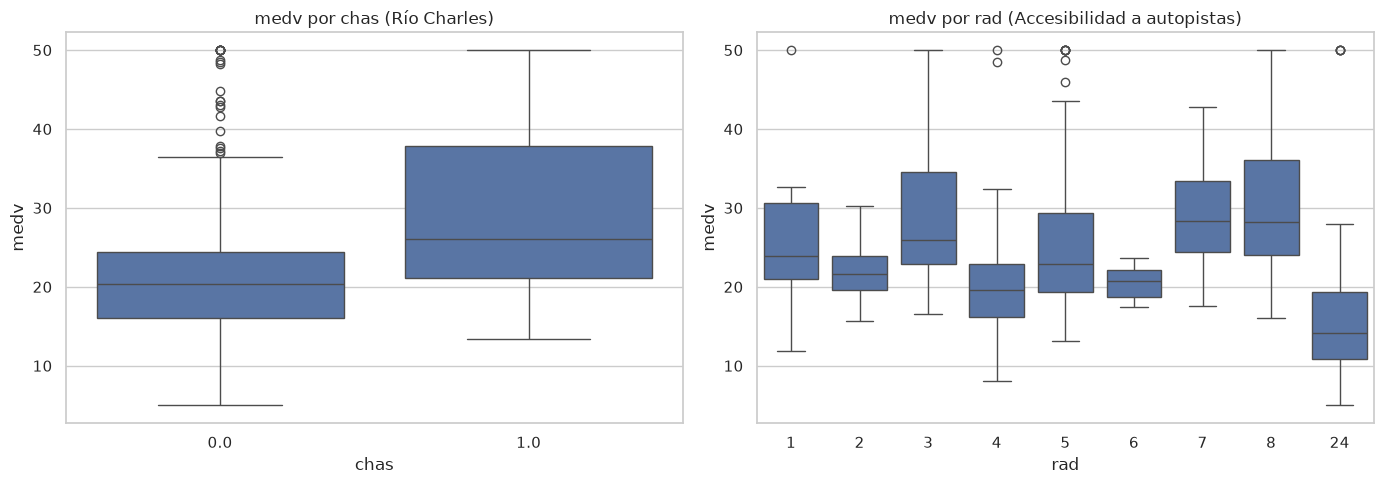

In [6]:
# chas vs medv
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Boxplot
df_chas = df[["chas", TARGET]].dropna()
sns.boxplot(data=df_chas, x="chas", y=TARGET, ax=axes[0])
axes[0].set_title("medv por chas (Río Charles)")

# Estadísticas por grupo
chas_stats = df_chas.groupby("chas")[TARGET].agg(["mean", "median", "std", "count"])
print("=== medv por chas ===")
print(chas_stats.round(4))

# Test de Mann-Whitney (no asume normalidad)
group_0 = df_chas[df_chas["chas"] == 0][TARGET]
group_1 = df_chas[df_chas["chas"] == 1][TARGET]
stat, p_value = stats.mannwhitneyu(group_0, group_1, alternative="two-sided")
print(f"\nTest Mann-Whitney U: estadístico={stat:.2f}, p-value={p_value:.6f}")
print(f"Diferencia significativa: {'Sí' if p_value < 0.05 else 'No'} (α=0.05)")

# rad vs medv
df_rad = df[["rad", TARGET]].dropna()
df_rad["rad"] = df_rad["rad"].astype(str)
sns.boxplot(data=df_rad, x="rad", y=TARGET, ax=axes[1], order=sorted(df_rad["rad"].unique(), key=int))
axes[1].set_title("medv por rad (Accesibilidad a autopistas)")

plt.tight_layout()
plt.show()

### Relaciones entre pares de variables predictoras

In [7]:
# Pares de variables con alta correlación entre sí
corr_matrix = df[NUMERIC_COLS].corr()

# Extraer pares con correlación > 0.7
HIGH_CORR_THRESHOLD = 0.7
pairs = []
for i in range(len(NUMERIC_COLS)):
    for j in range(i + 1, len(NUMERIC_COLS)):
        corr_val = corr_matrix.iloc[i, j]
        if abs(corr_val) > HIGH_CORR_THRESHOLD:
            pairs.append((NUMERIC_COLS[i], NUMERIC_COLS[j], corr_val))

print(f"=== Pares con correlación > {HIGH_CORR_THRESHOLD} ===")
for col1, col2, corr_val in sorted(pairs, key=lambda x: abs(x[2]), reverse=True):
    print(f"  {col1} - {col2}: r = {corr_val:.4f}")

=== Pares con correlación > 0.7 ===
  nox - dis: r = -0.7678
  age - dis: r = -0.7624
  indus - nox: r = 0.7383
  nox - age: r = 0.7283
  indus - dis: r = -0.7131
  indus - tax: r = 0.7074


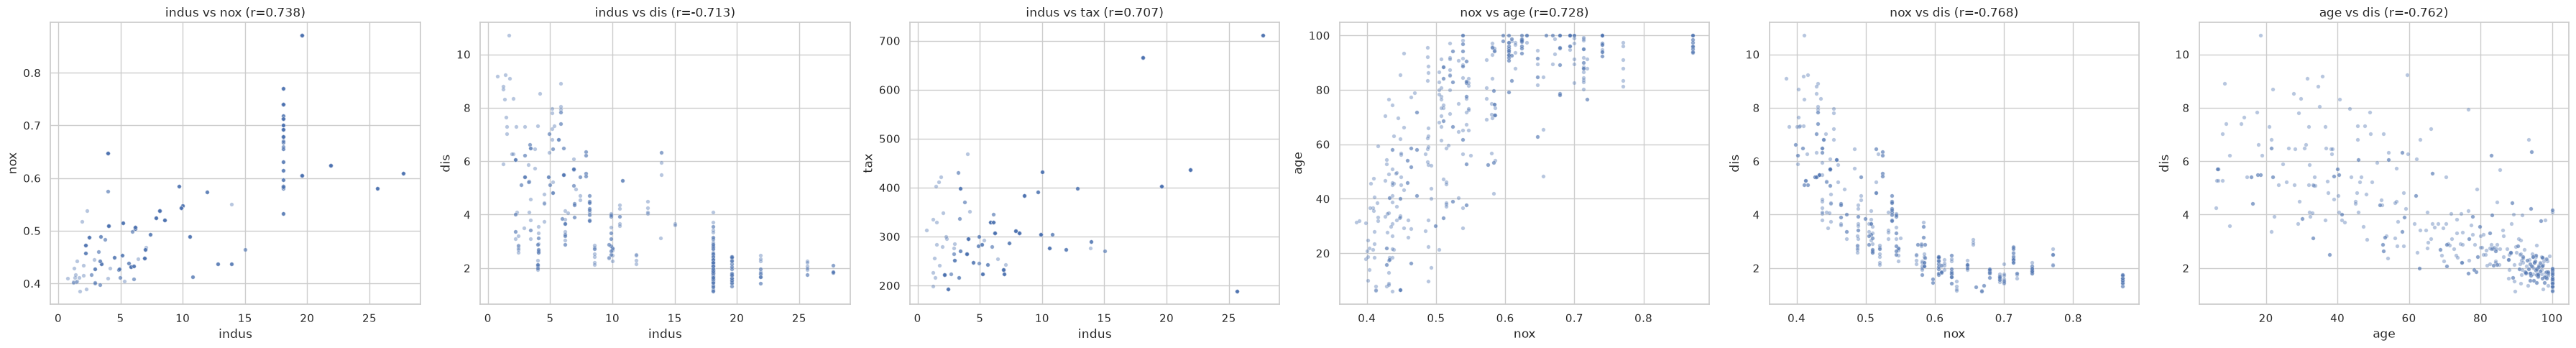

In [8]:
# Visualizar los pares más correlacionados
if pairs:
    n_pairs = len(pairs)
    fig, axes = plt.subplots(1, n_pairs, figsize=(6 * n_pairs, 5))
    if n_pairs == 1:
        axes = [axes]

    for idx, (col1, col2, corr_val) in enumerate(pairs):
        mask = df[[col1, col2]].dropna().index
        sns.scatterplot(x=df.loc[mask, col1], y=df.loc[mask, col2], ax=axes[idx], alpha=0.4, s=15)
        axes[idx].set_title(f"{col1} vs {col2} (r={corr_val:.3f})")

    plt.tight_layout()
    plt.show()
else:
    print("No se encontraron pares con alta correlación.")

## 📊 Analysis of Results and Conclusions

### Resultados del análisis bivariable

1. **Variables con mayor correlación con `medv`**:
   - `lstat` (r = -0.756): la variable más predictiva. A mayor porcentaje de población de estatus bajo, menor precio.
   - `rm` (r = 0.689): relación positiva fuerte. Más habitaciones = mayor precio.
   - `ptratio` (r = -0.466): relación negativa moderada. Más alumnos por profesor = menor precio.

2. **Relaciones no lineales**: la relación `lstat` vs `medv` muestra una curva que sugiere una transformación logarítmica. `rm` vs `medv` es más lineal pero con mayor dispersión en valores altos.

3. **Variable `chas`**: las viviendas junto al río Charles tienen un precio mediano mayor, y la diferencia es estadísticamente significativa.

4. **Variable `rad`**: los valores extremos (rad=24) están asociados a precios más bajos.

5. **Multicolinealidad**: se identificaron pares de variables con alta correlación entre sí, lo que indica potencial multicolinealidad a considerar en el modelado.

### Conclusiones

- `lstat` y `rm` son las dos variables más importantes para predecir el precio.
- Existen relaciones no lineales que sugieren la necesidad de transformaciones.
- Hay multicolinealidad entre predictores que podría afectar a modelos lineales.

## 💡 Proposals and Ideas

1. Aplicar transformación `log(1 + lstat)` para linealizar la relación con medv.
2. Considerar crear interacciones como `rm * lstat` o `rm²`.
3. Evaluar VIF (Variance Inflation Factor) en el feature engineering para manejar multicolinealidad.
4. Explorar modelos no lineales (Random Forest, Gradient Boosting) que capturen estas relaciones automáticamente.

## 📖 References

- Guía del proyecto (Tarea 3): [joserzapata.github.io/post/ciencia-datos-proyecto-python/3-analysis/](https://joserzapata.github.io/post/ciencia-datos-proyecto-python/3-analysis/)
- Seaborn regression plots: [seaborn.pydata.org/generated/seaborn.regplot.html](https://seaborn.pydata.org/generated/seaborn.regplot.html)
- Mann-Whitney U test: [scipy.stats.mannwhitneyu](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.mannwhitneyu.html)